<a href="https://colab.research.google.com/github/GopalGajrani/Computer-Vision/blob/main/csot_cv_week1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**COMPUTER VISION WEEK1**

##Pipeline

1. Data Collection
2. Data Loading & Transformation (including target_transform for labels and transform for features)
3. Data Batching (using DataLoader)
4. Model Definition
5. Loss Function Definition
6. [Optimizer Definition](https://colab.research.google.com/drive/1-QcpGygqtmqHGwnG6FSxMynsoIXsHiom#scrollTo=-3INoGQFfrkh&line=1&uniqifier=1)
7. Training Loop (feeding transformed batches to the model and calculating loss)
8. Evaluation/Inference

Import all the neccessary modules and the training and testing data

In [ ]:
!pip install matplotlib

In [ ]:
from ast import Lambda
import torch
from torch.utils.data import Dataset
from torchvision import datasets
import torch.nn.functional as F
from torchvision.transforms import v2
import matplotlib.pyplot as plt

train_transforms = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),         # 50% chance to flip the image left/right
    v2.RandomRotation(degrees=10),          # Randomly rotate between -10 and +10 degrees
    v2.RandomResizedCrop(size=(28, 28), scale=(0.9, 1.1)), # Slight zoom in/out

    # Essential formatting steps for PyTorch CNNs
    v2.ToImage(),                           # Convert to tensor format
    v2.ToDtype(torch.float32, scale=True),  # Convert to float and scale pixel values to [0, 1]

    # Optional: Normalize based on the dataset's specific mean and standard deviation
    # v2.Normalize(mean=[0.5], std=[0.5])
])

training_data=datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=train_transforms,
    target_transform=v2.Lambda(
        lambda y: F.one_hot(torch.tensor(y), num_classes=10).float()
    )
    )

testing_data=datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(),v2.ToDtype(torch.float32,scale=True)]),
    target_transform=v2.Lambda(
        lambda y: F.one_hot(torch.tensor(y), num_classes=10).float()
    )
)

Let's check the first label to confirm it's one-hot encoded.

In [ ]:
image, label = training_data[0]
print(f"Sample label value: {label}")
# print(f"Sample label shape: {label.shape}")
# print(f"Sample label data type: {label.dtype}")

# You can also check the sum of the elements for a one-hot encoded vector, it should be 1.0
# print(f"Sum of label elements: {torch.sum(label)}")

Sample label value: tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])


In [ ]:
print(training_data[0][0].shape)

torch.Size([1, 28, 28])


In [ ]:
print(training_data.transform)

Compose(
      RandomHorizontalFlip(p=0.5)
      RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
      RandomResizedCrop(size=(28, 28), scale=(0.9, 1.1), ratio=(0.75, 1.3333333333333333), interpolation=bilinear, antialias=True)
      ToImage()
      ToDtype(scale=True)
)


In [ ]:

image, label = training_data[0]

# Flatten the image. The 'start_dim=1' means we keep the batch dimension if there was one,
# but since our image is [1, 28, 28], it will flatten from the channel dimension onwards.
# The result will be a 1D tensor.
flattened_image = torch.flatten(image, start_dim=1)

print(f"Original image shape: {image.shape}")
print(f"Flattened image shape: {flattened_image.shape}")

Original image shape: torch.Size([1, 28, 28])
Flattened image shape: torch.Size([1, 784])


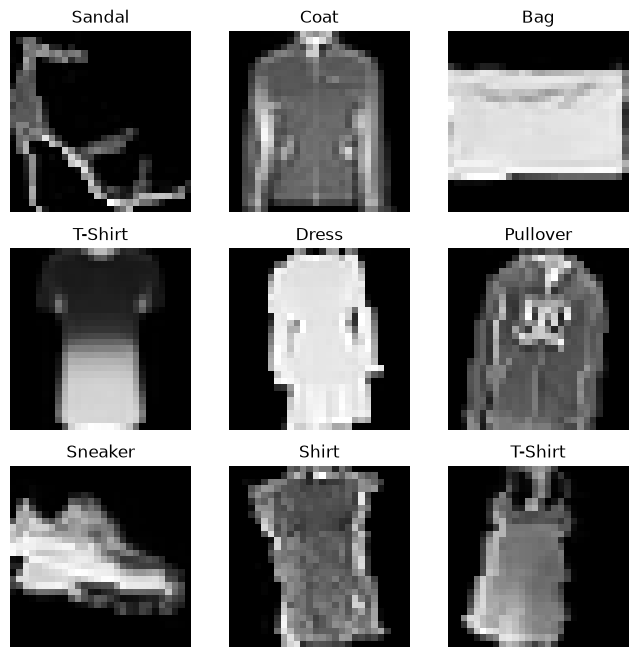

In [ ]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    # Convert one-hot encoded label back to an integer index for display
    plt.title(labels_map[label.argmax().item()])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [ ]:
import os
import torch
from torch import nn
from torch.utils.data import DataLoader

In [ ]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [ ]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(testing_data, batch_size=64, shuffle=True)

#MODEL

##Convolutional Neural Network (CNN)
Define a class for CNN with initializing all the properties you want you image to go through and then define the pipeline in forward function. Softmax need not to be implemented here since the `nn.CrossEntropyLoss` automatically applies softmax activation to `logits`.

In [ ]:
class CNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1=nn.Conv2d(in_channels=1,out_channels=32,kernel_size=3,stride=1,padding=1)
    self.pool1=nn.MaxPool2d(kernel_size=2,stride=2)

    self.conv2=nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3,stride=1,padding=1)
    self.pool2=nn.MaxPool2d(kernel_size=2,stride=2)

    self.fc1=nn.Linear(in_features=64*7*7,out_features=128,bias=True)
    self.drop=nn.Dropout(0.5)
    self.fc2=nn.Linear(in_features=128,out_features=10,bias=True)

    self.flatten=nn.Flatten()
    self.relu=nn.ReLU(inplace=True)



  def forward(self,x):
    x=self.conv1(x)
    x=self.relu(x)
    x=self.pool1(x)

    x=self.conv2(x)
    x=self.relu(x)
    x=self.pool2(x)

    x=self.flatten(x)
    x=self.fc1(x)
    x=self.relu(x)
    x=self.drop(x)
    x=self.fc2(x)

    return x

In [ ]:
model_cnn=CNN().to(device)
print(model_cnn.eval())

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (drop): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (relu): ReLU(inplace=True)
)


##HyperParameters

In [ ]:
learning_rate = 1e-3
batch_size = 64
epochs = 5

#Loss Function

In [ ]:
# Initialize the loss function
loss_fn = nn.CrossEntropyLoss()

#Training Loop

Avoid re-running the training loop block multiple times blindly. Re-executing the training loop does not start the training over from scratch. It will continue training the existing model, which can quickly lead to overfitting (where the model memorizes the training data and loses the ability to recognize new images).

In [ ]:
optimizer = torch.optim.SGD(model_cnn.parameters(), lr=learning_rate)

In [ ]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        # Move data to the same device as the model
        X, y = X.to(device), y.to(device)

        # Compute prediction and loss

        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * batch_size + len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")


def test_loop(dataloader, model, loss_fn):
    # Set the model to evaluation mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for X, y in dataloader:
            # Move data to the same device as the model
            X, y = X.to(device), y.to(device)

            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            # Corrected: Compare predicted class indices with true class indices (from one-hot 'y')
            correct += (pred.argmax(1) == y.argmax(1)).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

#Run the loop and Data Set

Run this cell for training and evaluating data on normal neural network

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

epochs = 10
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loop(test_dataloader, model, loss_fn)
print("Done!")

NameError: name 'model' is not defined

Currently the best model with accuracy of 92% using adam optimization and CNN only.

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

epochs = 10
for t in range(epochs):
    print(f"Epoch CNN {t+1}\n-------------------------------")
    train_loop(train_dataloader, model_cnn, loss_fn, optimizer)
    test_loop(test_dataloader, model_cnn, loss_fn)
print("Done!")

Epoch CNN 1
-------------------------------
loss: 2.310605  [   64/60000]
loss: 2.298993  [ 6464/60000]
loss: 2.293354  [12864/60000]
loss: 2.300763  [19264/60000]
loss: 2.304029  [25664/60000]
loss: 2.297742  [32064/60000]
loss: 2.300365  [38464/60000]
loss: 2.301958  [44864/60000]
loss: 2.316676  [51264/60000]
loss: 2.302690  [57664/60000]
Test Error: 
 Accuracy: 19.9%, Avg loss: 2.302092 

Epoch CNN 2
-------------------------------
loss: 2.316394  [   64/60000]
loss: 2.295763  [ 6464/60000]
loss: 2.291242  [12864/60000]
loss: 2.298803  [19264/60000]
loss: 2.295845  [25664/60000]
loss: 2.293691  [32064/60000]
loss: 2.309530  [38464/60000]
loss: 2.302857  [44864/60000]
loss: 2.298163  [51264/60000]
loss: 2.290559  [57664/60000]
Test Error: 
 Accuracy: 19.9%, Avg loss: 2.302062 

Epoch CNN 3
-------------------------------
loss: 2.301727  [   64/60000]
loss: 2.318488  [ 6464/60000]
loss: 2.303283  [12864/60000]
loss: 2.305817  [19264/60000]
loss: 2.299510  [25664/60000]
loss: 2.301944

Let's try running the model using adam's optimization .

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=learning_rate)

epochs = 10
for t in range(epochs):
    print(f"Epoch CNN_Adam_Data_Augmentation{t+1}\n-------------------------------")
    train_loop(train_dataloader, model_cnn, loss_fn, optimizer)
    test_loop(test_dataloader, model_cnn, loss_fn)
print("Done!")

Epoch CNN_Adam_Data_Augmentation1
-------------------------------
loss: 2.291924  [   64/60000]



KeyboardInterrupt



In [ ]:
model=CNN().to(device)